In [ ]:
# load libraries

import sqlalchemy as smy
from sqlalchemy import create_engine
import psycopg2 as pys
import pandas as pd
from sqlalchemy.engine import URL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import MonthBegin
import statsmodels.api as sm
import statsmodels.api as sm
import patsy
from sklearn.cluster import KMeans

In [ ]:
import os
os.getcwd()

## 1. Projects Dataset

In [ ]:
# load data
projects_data = pd.read_csv("data/base_data_for_model.csv")

# Set seed to ensure reproducibility
np.random.seed(100)

# convert the qualitative variables to categorical variables
projects_data['project_state'] = projects_data['project_state'].astype('category')
projects_data['project_city'] = projects_data['project_city'].astype('category')
projects_data['project_category'] = projects_data['project_category'].astype('category')
projects_data['project_type'] = projects_data['project_type'].astype('category')
projects_data['acf'] = projects_data['acf'].astype('category')
projects_data['area_type'] = projects_data['area_type'].astype('category')
projects_data['year'] = projects_data['year'].astype('category')
projects_data['county_name'] = projects_data['county_name'].astype('category')
projects_data['official_budget_range'] = projects_data['official_budget_range'].astype('category')
projects_data['ciqs_complexity_category'] = projects_data['ciqs_complexity_category'].astype('category')


# logarithmic trasnformation on project total cost
projects_data['log_project_cost'] = np.log(projects_data["total_project_cost_normalized_2025"])

# checks the dimension of the project dataframe
print("The size of the projects_data frame is", projects_data.shape)

# Display the first few rows of the dataset
projects_data.head()

The size of the projects_data frame is (17025, 39)


C:\Users\nkafwimi\AppData\Local\Temp\ipykernel_10460\3750967997.py:2: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  projects_data = pd.read_csv("base_data_for_model.csv")


,project_id,project_name,project_latitude,project_longitude,project_phase_id,phase_description,project_type,project_category,construction_category,project_city,...,area_type,year,cpi,inflation_factor,total_project_cost_normalized_2025,official_budget_range,ciqs_complexity_category,complexity_numeric,budget_midpoint,log_project_cost
0,MDAwMDBUMDI0X1RSQUZGSUMgU0lHTlNfQSBIIENPLiwgSU...,"TRAFFIC SIGNS - A H CO., INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,288970.919046,Less than $1M,Category 2,2.0,0,12.574081
1,MDAwMDBUMDI1X1RSQUZGSUMgU0lHTlNfSyBXIEVMRUNUUk...,"TRAFFIC SIGNS - K W ELECTRIC, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,626756.883848,Less than $1M,Category 2,2.0,0,13.348314
2,MDAwMDBUMDI2X1RSQUZGSUMgU0lHTlNfSyBXIEVMRUNUUk...,"TRAFFIC SIGNS - K W ELECTRIC, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,301033.852171,Less than $1M,Category 2,2.0,0,12.614978
3,MDAwMDBUMDIzX1RSQUZGSUMgU0lHTlNfQ09MTElOUyBIRV...,"TRAFFIC SIGNS - COLLINS HERMANN, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2018.0,251.1,1.277579,468061.381123,Less than $1M,Category 2,2.0,0,13.056355
4,MDAwMDBUMDk1X1RSQUZGSUMgU0lHTlNfQ09MTElOUyBIRV...,"TRAFFIC SIGNS - COLLINS HERMANN, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2020.0,258.8,1.239567,123956.723338,Less than $1M,Category 1,1.0,0,11.727688


In [ ]:
# Split the data into 80% training and 20% test sets
# Drop irrelevant columns
# projects_data = projects_data.drop(columns=[
#     'project_id', 'project_name', 'project_phase_id', 'phase_description', 'construction_category',
#     'labor_total_calc', 'material_total_calc', 'equipment_total_calc', 'other_cost1_calc',
#     'other_cost2_calc', 'other_cost3_calc', 'other_cost3_calc.1'
# ])

# Get dimensions
rows, cols = projects_data.shape

# Print summary
print(f"The projects dataframe has {rows} rows and {cols} predictors after excluding irrelevant variables")

# splitting the data into training and test sets
test_rows = np.random.choice(projects_data.index, size=int(0.2 * len(projects_data)), replace=False)
test_projects_data = projects_data.loc[test_rows]                                 # train dataset
train_projects_data = projects_data.drop(test_rows).reset_index(drop=True)          # test dataset


# Display the first few rows of the training dataset
train_projects_data.head()

The projects dataframe has 17025 rows and 39 predictors after excluding irrelevant variables


,project_id,project_name,project_latitude,project_longitude,project_phase_id,phase_description,project_type,project_category,construction_category,project_city,...,area_type,year,cpi,inflation_factor,total_project_cost_normalized_2025,official_budget_range,ciqs_complexity_category,complexity_numeric,budget_midpoint,log_project_cost
0,MDAwMDBUMDI0X1RSQUZGSUMgU0lHTlNfQSBIIENPLiwgSU...,"TRAFFIC SIGNS - A H CO., INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,288970.919046,Less than $1M,Category 2,2.0,0,12.574081
1,MDAwMDBUMDI2X1RSQUZGSUMgU0lHTlNfSyBXIEVMRUNUUk...,"TRAFFIC SIGNS - K W ELECTRIC, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,301033.852171,Less than $1M,Category 2,2.0,0,12.614978
2,MDAwMDBUMDk1X1RSQUZGSUMgU0lHTlNfQ09MTElOUyBIRV...,"TRAFFIC SIGNS - COLLINS HERMANN, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2020.0,258.8,1.239567,123956.723338,Less than $1M,Category 1,1.0,0,11.727688
3,MDAwMDBUMDk2X1RSQUZGSUMgU0lHTlNfQ09MTElOUyBIRV...,"TRAFFIC SIGNS - COLLINS HERMANN, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,296380.558467,Less than $1M,Category 2,2.0,0,12.599400
4,MDAwMDBUMDk3X1RSQUZGSUMgU0lHTlNfQ09MTElOUyBIRV...,"TRAFFIC SIGNS - COLLINS HERMANN, INC. bid",41.5861,-93.625,NaN,NaN,Pavement Markers,Civil,"Civil, Infrastructure & Landscaping",STATEWIDE,...,Rural,2019.0,255.7,1.254595,306678.276105,Less than $1M,Category 2,2.0,0,12.633555


## 2. EDA

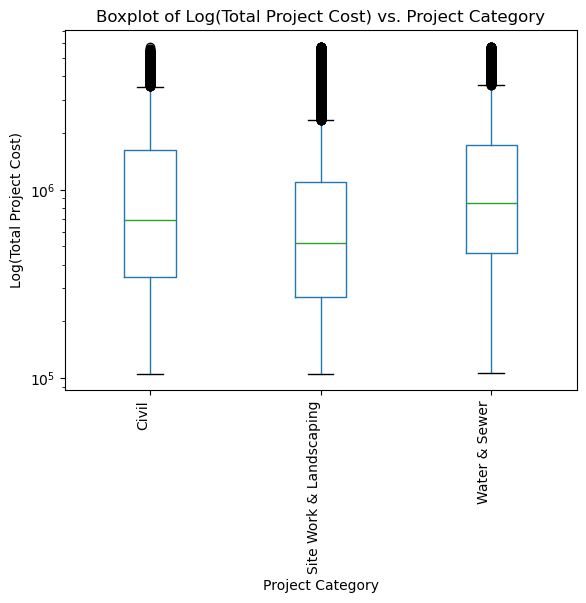

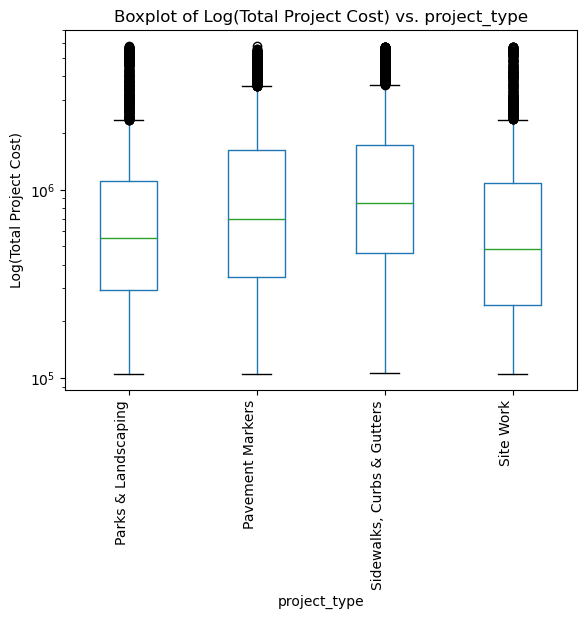

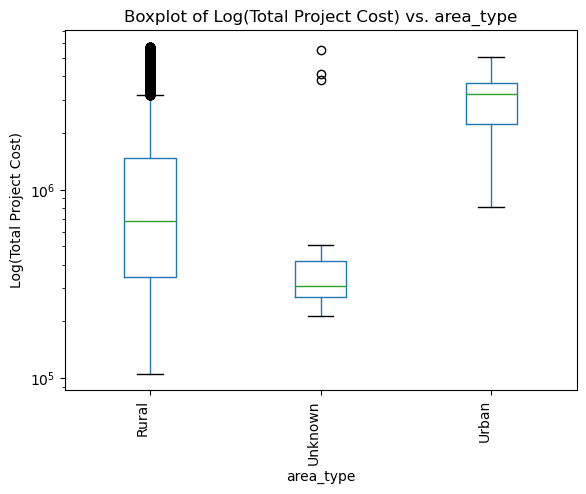

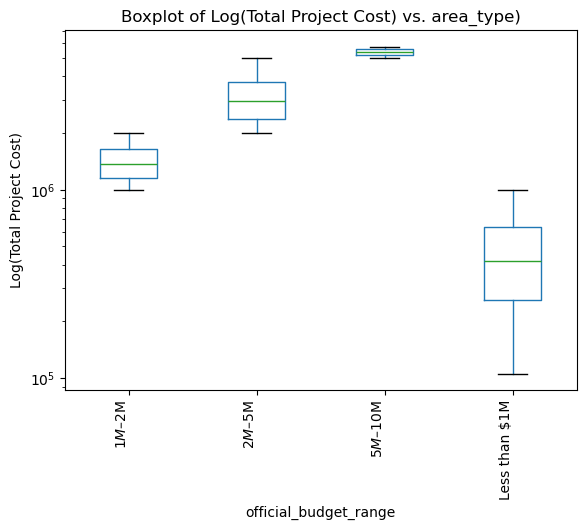

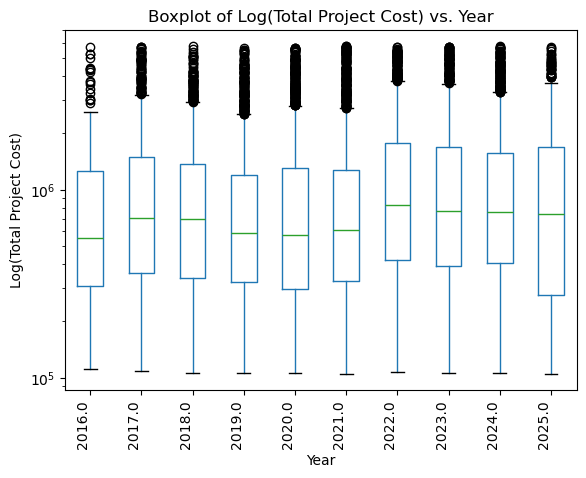

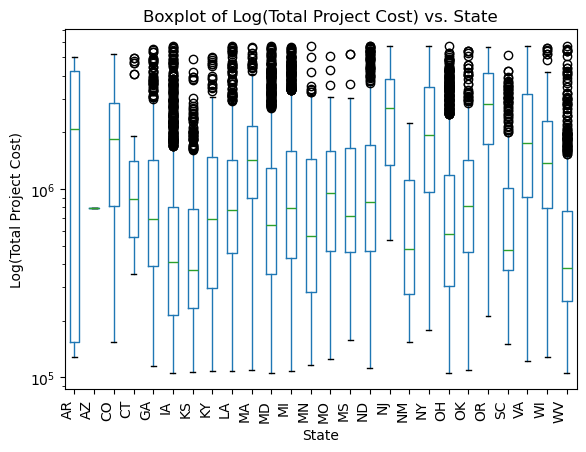

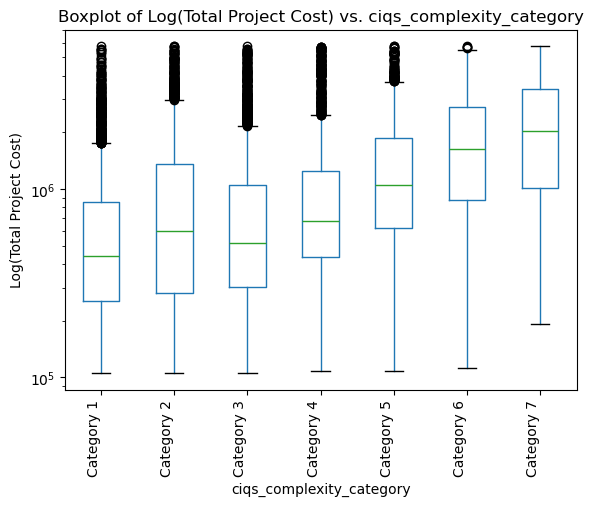

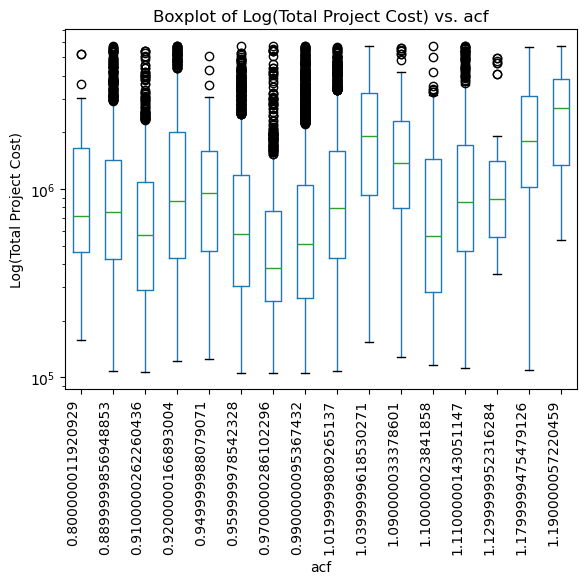

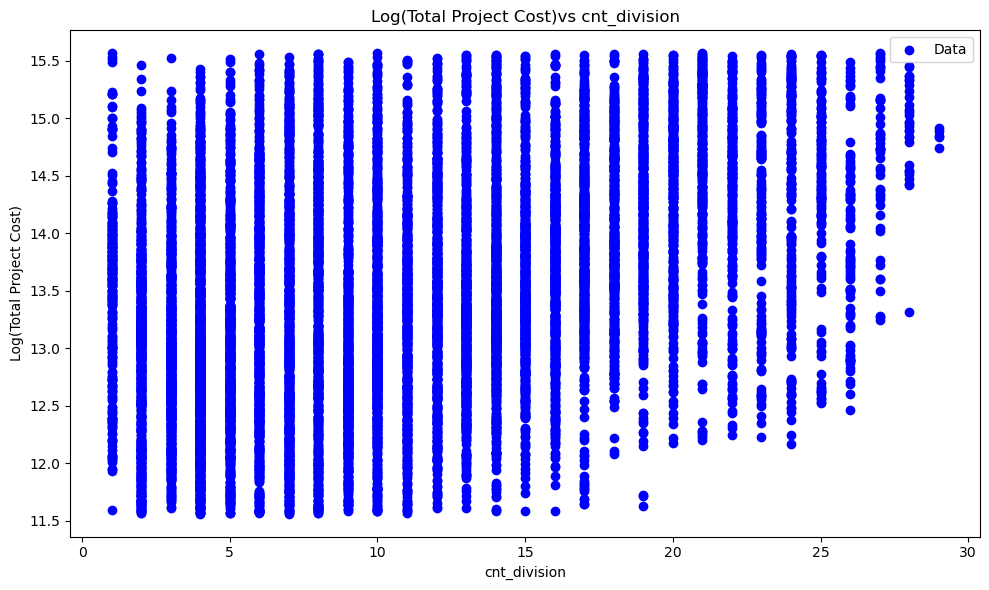

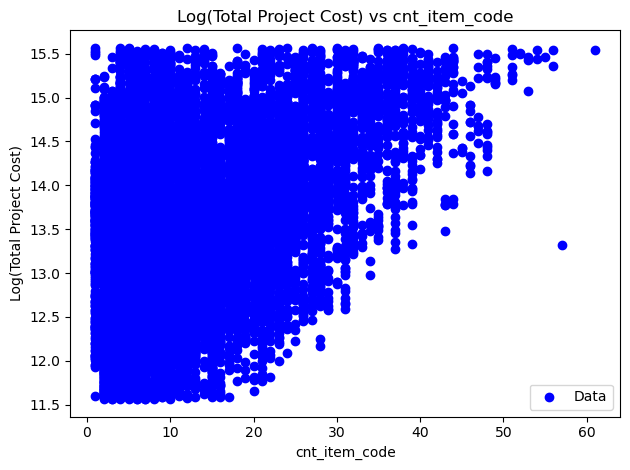

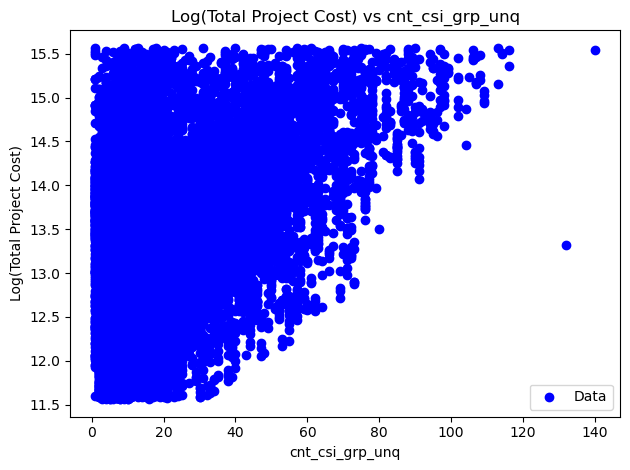

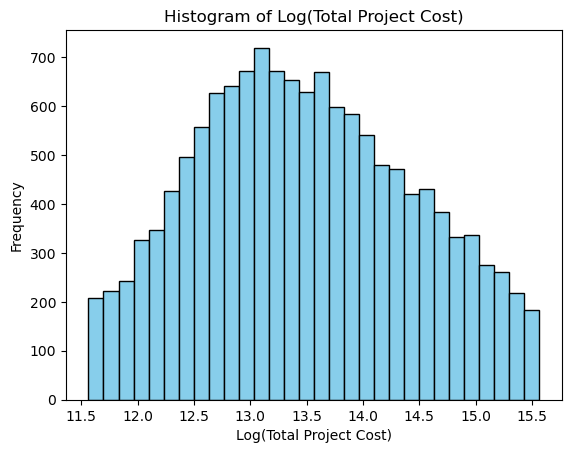

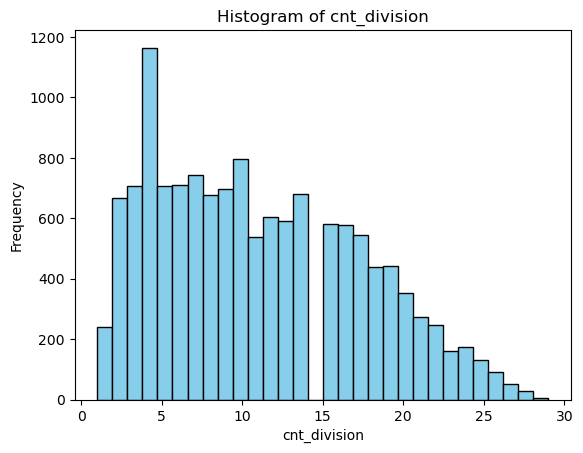

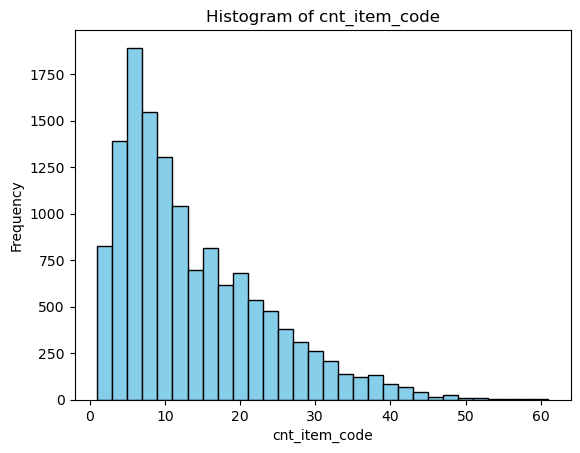

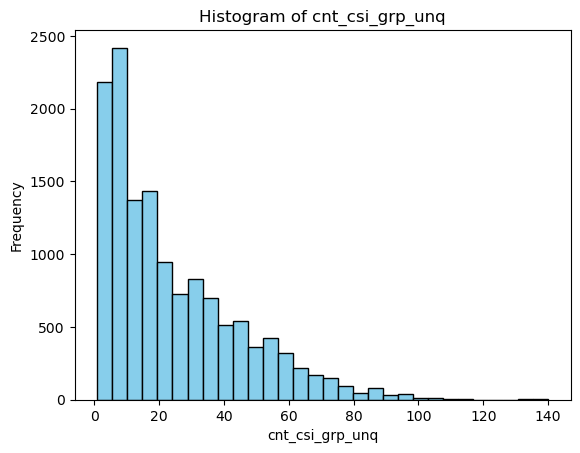

In [ ]:
#### EDA ####

# Boxplots for qualitative variables
# Boxplot of Log(Total Project Cost) vs. Project Category
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='project_category', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. Project Category')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('Project Category')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. Project Type
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='project_type', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. project_type')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('project_type')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. Area Type
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='area_type', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. area_type')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('area_type')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. Budget Range
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='official_budget_range', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. area_type)')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('official_budget_range')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. Year
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='year', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. Year')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('Year')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. State
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='project_state', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. State')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('State')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. Complexity Category
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='ciqs_complexity_category', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. ciqs_complexity_category')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('ciqs_complexity_category')
plt.ylabel('Log(Total Project Cost)')
plt.show()

# Boxplot of Log(Total Project Cost) vs. ACF
train_projects_data.boxplot(column='total_project_cost_normalized_2025', by='acf', grid=False)
plt.yscale('log')
plt.xticks(rotation=90, ha="right")
plt.title('Boxplot of Log(Total Project Cost) vs. acf')
plt.suptitle('')  # Suppress the default title to avoid duplication
plt.xlabel('acf')
plt.ylabel('Log(Total Project Cost)')
plt.show()



# Scatterplots for quantitative variables
# Define the plot
plt.figure(figsize=(10, 6))

# Scatter plot of Log(Total Project Cost) vs. Project Sq. Ft
plt.scatter(train_projects_data['cnt_division'], train_projects_data['log_project_cost'], color='blue', label='Data')

# Customize the plot
plt.xlabel('cnt_division')
plt.ylabel('Log(Total Project Cost)')
plt.title('Log(Total Project Cost)vs cnt_division')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


# # Scatter plot of Log(Total Project Cost) vs. cnt_item_code
plt.scatter(train_projects_data['cnt_item_code'], train_projects_data['log_project_cost'], color='blue', label='Data')

# Customize the plot
plt.xlabel('cnt_item_code')
plt.ylabel('Log(Total Project Cost)')
plt.title('Log(Total Project Cost) vs cnt_item_code')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


# Scatter plot of Log(Total Project Cost) vs. cnt_csi_grp_unq
plt.scatter(train_projects_data['cnt_csi_grp_unq'], train_projects_data['log_project_cost'], color='blue', label='Data')

# Customize the plot
plt.xlabel('cnt_csi_grp_unq')
plt.ylabel('Log(Total Project Cost)')
plt.title('Log(Total Project Cost) vs cnt_csi_grp_unq')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# Histograms for quantitative variables

# Histogram of Log (Total Project Cost)
plt.hist(train_projects_data['log_project_cost'], bins=30, color='skyblue', edgecolor='black')
# Adding labels and title
plt.xlabel('Log(Total Project Cost)')
plt.ylabel('Frequency')
plt.title('Histogram of Log(Total Project Cost)')

# Display the plot
plt.show()

# Histogram of cnt_division
plt.hist(train_projects_data['cnt_division'], bins=30, color='skyblue', edgecolor='black')
# Adding labels and title
plt.xlabel('cnt_division')
plt.ylabel('Frequency')
plt.title('Histogram of cnt_division')

# Display the plot
plt.show()

# Histogram of cnt_item_code
plt.hist(train_projects_data['cnt_item_code'], bins=30, color='skyblue', edgecolor='black')
# Adding labels and title
plt.xlabel('cnt_item_code')
plt.ylabel('Frequency')
plt.title('Histogram of cnt_item_code')

# Display the plot
plt.show()

# Histogram of cnt_csi_grp_unq
plt.hist(train_projects_data['cnt_csi_grp_unq'], bins=30, color='skyblue', edgecolor='black')
# Adding labels and title
plt.xlabel('cnt_csi_grp_unq')
plt.ylabel('Frequency')
plt.title('Histogram of cnt_csi_grp_unq')

# Display the plot
plt.show()

In [ ]:
# check the correlation among qualitative variables
train_projects_data[["total_project_cost_normalized_2025", 'cnt_division','cnt_item_code','cnt_csi_grp_unq']].corr()

,total_project_cost_normalized_2025,cnt_division,cnt_item_code,cnt_csi_grp_unq
total_project_cost_normalized_2025,1.000000,0.373713,0.423809,0.431553
cnt_division,0.373713,1.000000,0.895749,0.932784
cnt_item_code,0.423809,0.895749,1.000000,0.967787
cnt_csi_grp_unq,0.431553,0.932784,0.967787,1.000000


### 3. Multiple Linear Regression

In [ ]:
# a. fit a multi-linear regression model with all predictors
formula = 'log_project_cost ~  project_type + acf + year + project_category + project_city + project_state + cnt_csi_grp_unq + cnt_division + cnt_item_code + county_name + area_type + official_budget_range + ciqs_complexity_category'

# Create the design matrices using patsy
y, X = patsy.dmatrices(formula, data=train_projects_data, return_type='dataframe')

# Fit the multiple linear regression model
model1 = sm.OLS(y, X).fit()

# Print the model summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:       log_project_cost   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     67.86
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:59:19   Log-Likelihood:                -6898.6
No. Observations:               13593   AIC:                         1.557e+04
Df Residuals:                   12709   BIC:                         2.221e+04
Df Model:                         883                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [ ]:
# b. fit a multi-linear regression model without county_name and project_city
formula = 'log_project_cost ~  project_type + acf + year + project_category + project_state + cnt_csi_grp_unq + cnt_division + cnt_item_code + area_type + official_budget_range + ciqs_complexity_category'

# Create the design matrices using patsy
y, X = patsy.dmatrices(formula, data=train_projects_data, return_type='dataframe')

# Fit the multiple linear regression model
model2 = sm.OLS(y, X).fit()

# Print the model summary
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:       log_project_cost   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     956.0
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:59:20   Log-Likelihood:                -8401.5
No. Observations:               13620   AIC:                         1.691e+04
Df Residuals:                   13568   BIC:                         1.730e+04
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:
# c. fit a multi-linear regression model without state and project_city
formula = 'log_project_cost ~  project_type + acf + year + project_category + county_name + cnt_csi_grp_unq + cnt_division + cnt_item_code + area_type + official_budget_range + ciqs_complexity_category'

# Create the design matrices using patsy
y, X = patsy.dmatrices(formula, data=train_projects_data, return_type='dataframe')

# Fit the multiple linear regression model
model3 = sm.OLS(y, X).fit()

# Print the model summary
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_project_cost   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     79.17
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:59:21   Log-Likelihood:                -7357.6
No. Observations:               13620   AIC:                         1.614e+04
Df Residuals:                   12909   BIC:                         2.148e+04
Df Model:                         710                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [ ]:
# d. fit a multi-linear regression model without cnt_division and  cnt_item_code
formula = 'log_project_cost ~  project_type + acf + year + project_category + project_city + project_state + cnt_csi_grp_unq + county_name + area_type + official_budget_range + ciqs_complexity_category'

# Create the design matrices using patsy
y, X = patsy.dmatrices(formula, data=train_projects_data, return_type='dataframe')

# Fit the multiple linear regression model
model4 = sm.OLS(y, X).fit()

# Print the model summary
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:       log_project_cost   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     67.85
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:59:29   Log-Likelihood:                -6913.1
No. Observations:               13593   AIC:                         1.559e+04
Df Residuals:                   12711   BIC:                         2.222e+04
Df Model:                         881                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

### Outlier identification

C:\Users\nkafwimi\AppData\Local\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
C:\Users\nkafwimi\AppData\Local\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: divide by zero encountered in divide
  return self.resid / sigma / np.sqrt(1 - hii)
C:\Users\nkafwimi\AppData\Local\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:867: RuntimeWarning: divide by zero encountered in divide
  cooks_d2 *= hii / (1 - hii)


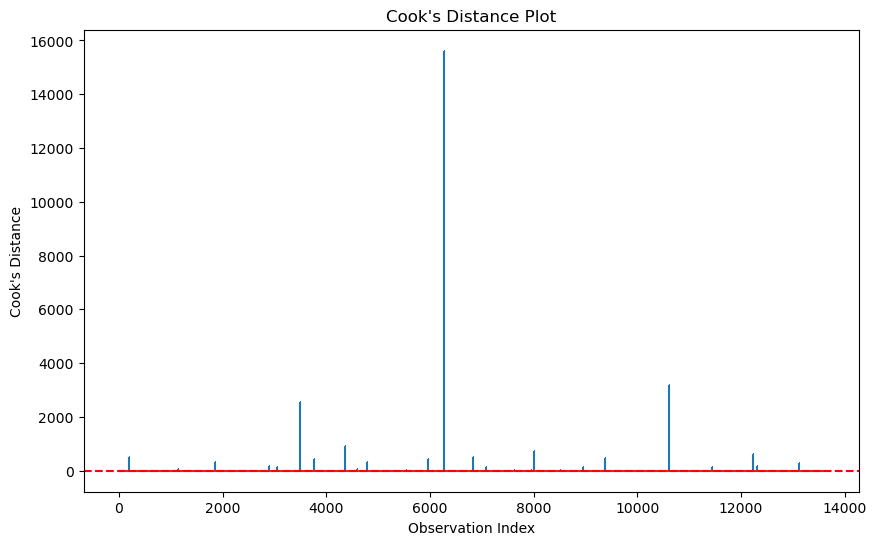

Number of outliers: 51


In [ ]:
# Calculate Cook's distances
influence = model4.get_influence()
cooks_d = influence.cooks_distance[0]

# Plot Cook's distances
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(y=4/len(train_projects_data), color='r', linestyle='--')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")
plt.show()

# Identify outliers
outliers = np.where(cooks_d > 0.002)[0]
num_outliers = len(outliers)
print(f"Number of outliers: {num_outliers}")

# remove outliers from the dataset
train_projects_data_outliers = train_projects_data.drop(outliers).reset_index(drop=True)

In [ ]:
outliers2 = np.where(cooks_d > 4/len(train_projects_data))[0]
num_outliers = len(outliers2)
print(f"Number of outliers: {num_outliers}")

# remove outliers from the dataset
train_projects_data_outliers2 = train_projects_data.drop(outliers).reset_index(drop=True)

Number of outliers: 272


In [ ]:
# fit a multi-linear regression model without outliers
formula = 'log_project_cost ~  project_type + acf + year + project_category + project_city + project_state + cnt_csi_grp_unq + county_name + area_type + official_budget_range + ciqs_complexity_category'

# Create the design matrices using patsy
y, X = patsy.dmatrices(formula, data = train_projects_data_outliers, return_type='dataframe')

# Fit the multiple linear regression model
model_outliers = sm.OLS(y, X).fit()

# Print the model summary
print(model_outliers.summary())


                            OLS Regression Results                            
Dep. Variable:       log_project_cost   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     67.51
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:59:37   Log-Likelihood:                -6896.1
No. Observations:               13542   AIC:                         1.555e+04
Df Residuals:                   12661   BIC:                         2.217e+04
Df Model:                         880                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [ ]:
# fit a multi-linear regression model without outliers based on threshold
formula = 'log_project_cost ~  project_type + acf + year + project_category + project_city + project_state + cnt_csi_grp_unq + county_name + area_type + official_budget_range + ciqs_complexity_category'

# Create the design matrices using patsy
y, X = patsy.dmatrices(formula, data = train_projects_data_outliers2, return_type='dataframe')

# Fit the multiple linear regression model
model_outliers2 = sm.OLS(y, X).fit()

# Print the model summary
print(model_outliers2.summary())


                            OLS Regression Results                            
Dep. Variable:       log_project_cost   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     67.51
Date:                Mon, 24 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:59:45   Log-Likelihood:                -6896.1
No. Observations:               13542   AIC:                         1.555e+04
Df Residuals:                   12661   BIC:                         2.217e+04
Df Model:                         880                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

### 3. Model Fitting

### K-Means Clustering

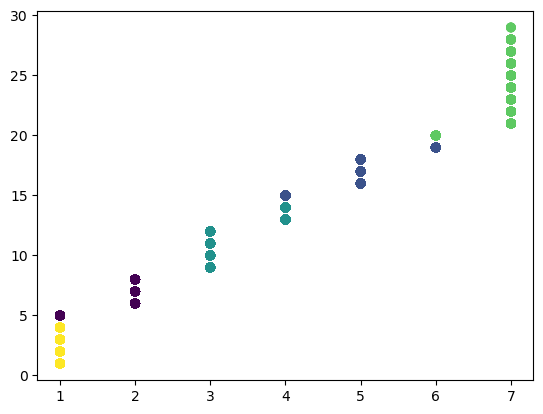

In [ ]:
# projects_data_filt = projects_data.drop(outliers).reset_index(drop=True)

kmeans = KMeans(n_clusters=5)
ypred = kmeans.fit_predict(projects_data[["complexity_numeric", "cnt_division"]])

plt.scatter(projects_data["complexity_numeric"], projects_data["cnt_division"], c=ypred)
plt.show()

In [ ]:
# assigning clusters to the dataset
projects_clustered = projects_data.copy()
projects_clustered["km_model2_cluster"] = ypred + 1

projects_clustered = projects_clustered[["project_type",
    "acf",
    "project_category",
    "project_city",
    "project_state",
    "cnt_csi_grp_unq",
    "county_name",
    "area_type",
    "year",
    "official_budget_range",
    "ciqs_complexity_category",
    "km_model2_cluster",
    "total_project_cost_normalized_2025"]].copy()

# creating subsets of data based on the computed clusters
projects_cluster1 = projects_clustered[projects_clustered["km_model2_cluster"] == 1].copy()
projects_cluster2 = projects_clustered[projects_clustered["km_model2_cluster"] == 2].copy()
projects_cluster3 = projects_clustered[projects_clustered["km_model2_cluster"] == 3].copy()
projects_cluster4 = projects_clustered[projects_clustered["km_model2_cluster"] == 4].copy()
projects_cluster5 = projects_clustered[projects_clustered["km_model2_cluster"] == 5].copy()

# splitting the datasets into training and testing data
def train_test_split_cluster(df, test_frac=0.2, random_state=42):
    test_idx = df.sample(frac=test_frac, random_state=random_state).index
    test_df = df.loc[test_idx].copy()
    train_df = df.drop(test_idx).copy()
    return train_df, test_df

trainData_cluster1, testData_cluster1 = train_test_split_cluster(projects_cluster1)
trainData_cluster2, testData_cluster2 = train_test_split_cluster(projects_cluster2)
trainData_cluster3, testData_cluster3 = train_test_split_cluster(projects_cluster3)
trainData_cluster4, testData_cluster4 = train_test_split_cluster(projects_cluster4)
trainData_cluster5, testData_cluster5 = train_test_split_cluster(projects_cluster5)

In [ ]:
print(len(projects_cluster1))
print(len(projects_cluster2))
print(len(projects_cluster3))
print(len(projects_cluster4))
print(len(projects_cluster5))

3553
3250
4857
1887
3478


### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
# Cluster 1

# Define X and target variable
y = trainData_cluster1["total_project_cost_normalized_2025"]
X = trainData_cluster1.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

y_testDT1 = testData_cluster1["total_project_cost_normalized_2025"]
X_test = testData_cluster1.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

# Identify categorical columns
categorical_cols = trainData_cluster1.select_dtypes(include=["object", "category"]).columns.tolist()

# Apply one-hot encoding to categorical features
encoder = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)], remainder="passthrough")
X_encoded = encoder.fit_transform(X) # Transform features
X_testDT1 = encoder.fit_transform(X_test) # Transform features

# Initialize decision tree classifier
dtree_modelC1 = DecisionTreeRegressor(random_state=100)
# Define cross-validation strategy
cv = KFold(n_splits=3, shuffle=True, random_state=100)
# Perform cross-validation predictions
y_pred = cross_val_predict(dtree_modelC1, X_encoded, y, cv=cv) # No method="predict"

# model42.fit(X_encoded, y)
dtC1 = dtree_modelC1.fit(X_encoded, y)
# Compute performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 112629963858.0274
Root Mean Squared Error (RMSE): 335603.8794
Mean Absolute Error (MAE): 195731.4929
Mean Absolute Percentage Error (MAPE): 27.70%
R-squared (R²): 0.9022


In [ ]:
# Cluster 2

# Define X and target variable
y = trainData_cluster2["total_project_cost_normalized_2025"]
X = trainData_cluster2.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

y_testDT2 = testData_cluster2["total_project_cost_normalized_2025"]
X_test = testData_cluster2.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

# Identify categorical columns
categorical_cols = trainData_cluster2.select_dtypes(include=["object", "category"]).columns.tolist()

# Apply one-hot encoding to categorical features
encoder = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)], remainder="passthrough")
X_encoded = encoder.fit_transform(X) # Transform features
X_testDT2 = encoder.fit_transform(X_test) # Transform features

# Initialize decision tree classifier
dtree_modelC2 = DecisionTreeRegressor(random_state=100)
# Define cross-validation strategy
cv = KFold(n_splits=3, shuffle=True, random_state=100)
# Perform cross-validation predictions
y_pred = cross_val_predict(dtree_modelC2, X_encoded, y, cv=cv) # No method="predict"

# model42.fit(X_encoded, y)
dtC2 = dtree_modelC2.fit(X_encoded, y)
# Compute performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 162944530938.4551
Root Mean Squared Error (RMSE): 403663.8836
Mean Absolute Error (MAE): 234015.1523
Mean Absolute Percentage Error (MAPE): 18.48%
R-squared (R²): 0.8763


In [ ]:
# Cluster 3

# Define X and target variable
y = trainData_cluster3["total_project_cost_normalized_2025"]
X = trainData_cluster3.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

# Identify categorical columns
categorical_cols = trainData_cluster3.select_dtypes(include=["object", "category"]).columns.tolist()

# Apply one-hot encoding to categorical features
encoder = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)], remainder="passthrough")
X_encoded = encoder.fit_transform(X) # Transform features

# Initialize decision tree classifier
dtree_modelC3 = DecisionTreeRegressor(random_state=100)
# Define cross-validation strategy
cv = KFold(n_splits=3, shuffle=True, random_state=100)
# Perform cross-validation predictions
y_pred = cross_val_predict(dtree_modelC3, X_encoded, y, cv=cv) # No method="predict"

# model42.fit(X_encoded, y)
# Compute performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 93320798059.7724
Root Mean Squared Error (RMSE): 305484.5300
Mean Absolute Error (MAE): 165937.6553
Mean Absolute Percentage Error (MAPE): 20.99%
R-squared (R²): 0.9137


In [ ]:
# Cluster 4

# Define X and target variable
y = trainData_cluster4["total_project_cost_normalized_2025"]
X = trainData_cluster4.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

# Identify categorical columns
categorical_cols = trainData_cluster4.select_dtypes(include=["object", "category"]).columns.tolist()

# Apply one-hot encoding to categorical features
encoder = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)], remainder="passthrough")
X_encoded = encoder.fit_transform(X) # Transform features

# Initialize decision tree classifier
dtree_modelC4 = DecisionTreeRegressor(random_state=100)
# Define cross-validation strategy
cv = KFold(n_splits=3, shuffle=True, random_state=100)
# Perform cross-validation predictions
y_pred = cross_val_predict(dtree_modelC4, X_encoded, y, cv=cv) # No method="predict"

# model42.fit(X_encoded, y)
# Compute performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 278011584543.1454
Root Mean Squared Error (RMSE): 527268.0386
Mean Absolute Error (MAE): 308450.6349
Mean Absolute Percentage Error (MAPE): 15.11%
R-squared (R²): 0.8670


In [ ]:
# Cluster 5

# Define X and target variable
y = trainData_cluster5["total_project_cost_normalized_2025"]
X = trainData_cluster5.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster" ])

# Identify categorical columns
categorical_cols = trainData_cluster5.select_dtypes(include=["object", "category"]).columns.tolist()

# Apply one-hot encoding to categorical features
encoder = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)], remainder="passthrough")
X_encoded = encoder.fit_transform(X) # Transform features

# Initialize decision tree classifier
dtree_modelC5 = DecisionTreeRegressor(random_state=100)
# Define cross-validation strategy
cv = KFold(n_splits=3, shuffle=True, random_state=100)
# Perform cross-validation predictions
y_pred = cross_val_predict(dtree_modelC5, X_encoded, y, cv=cv) # No method="predict"

# model42.fit(X_encoded, y)
# Compute performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 71162798390.9589
Root Mean Squared Error (RMSE): 266763.5627
Mean Absolute Error (MAE): 169533.7695
Mean Absolute Percentage Error (MAPE): 34.71%
R-squared (R²): 0.8628


### Random Forest

In [ ]:
# Cluster 1

# Define X and target variable
y = trainData_cluster1["total_project_cost_normalized_2025"]
X = trainData_cluster1.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster"])

# Identify categorical columns
categorical_cols = trainData_cluster1.select_dtypes(include=["object", "category"]).columns.tolist()

# One-hot encoding for categorical features
encoder = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough"
)

# Transform features
X_encoded = encoder.fit_transform(X)

# Initialize RANDOM FOREST regressor
rf_modelC1 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=100,
    n_jobs=-1
)

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=100)

# Cross-validated predictions
y_pred = cross_val_predict(rf_modelC1, X_encoded, y, cv=cv)

# Performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 88198467825.7130
Root Mean Squared Error (RMSE): 296982.2685
Mean Absolute Error (MAE): 182151.9655
Mean Absolute Percentage Error (MAPE): 27.20%
R-squared (R²): 0.9234


In [ ]:
# Cluster 2

# Define X and target variable
y = trainData_cluster2["total_project_cost_normalized_2025"]
X = trainData_cluster2.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster"])

# Identify categorical columns
categorical_cols = trainData_cluster2.select_dtypes(include=["object", "category"]).columns.tolist()

# One-hot encoding for categorical features
encoder = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough"
)

# Transform features
X_encoded = encoder.fit_transform(X)

# Initialize RANDOM FOREST regressor
rf_modelC2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=100,
    n_jobs=-1
)

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=100)

# Cross-validated predictions
y_pred = cross_val_predict(rf_modelC2, X_encoded, y, cv=cv)

# Performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 121154317064.2116
Root Mean Squared Error (RMSE): 348072.2871
Mean Absolute Error (MAE): 218662.0473
Mean Absolute Percentage Error (MAPE): 18.68%
R-squared (R²): 0.9080


In [ ]:
# Cluster 3

# Define X and target variable
y = trainData_cluster3["total_project_cost_normalized_2025"]
X = trainData_cluster3.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster"])

# Identify categorical columns
categorical_cols = trainData_cluster3.select_dtypes(include=["object", "category"]).columns.tolist()

# One-hot encoding for categorical features
encoder = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough"
)

# Transform features
X_encoded = encoder.fit_transform(X)

# Initialize RANDOM FOREST regressor
rf_modelC3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=100,
    n_jobs=-1
)

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=100)

# Cross-validated predictions
y_pred = cross_val_predict(rf_modelC3, X_encoded, y, cv=cv)

# Performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 80289180307.1850
Root Mean Squared Error (RMSE): 283353.4547
Mean Absolute Error (MAE): 163062.7437
Mean Absolute Percentage Error (MAPE): 22.28%
R-squared (R²): 0.9257


In [ ]:
# Cluster 4

# Define X and target variable
y = trainData_cluster4["total_project_cost_normalized_2025"]
X = trainData_cluster4.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster"])

# Identify categorical columns
categorical_cols = trainData_cluster4.select_dtypes(include=["object", "category"]).columns.tolist()

# One-hot encoding for categorical features
encoder = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough"
)

# Transform features
X_encoded = encoder.fit_transform(X)

# Initialize RANDOM FOREST regressor
rf_modelC4 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=100,
    n_jobs=-1
)

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=100)

# Cross-validated predictions
y_pred = cross_val_predict(rf_modelC4, X_encoded, y, cv=cv)

# Performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 205065660208.4465
Root Mean Squared Error (RMSE): 452841.7607
Mean Absolute Error (MAE): 287794.7966
Mean Absolute Percentage Error (MAPE): 14.51%
R-squared (R²): 0.9019


In [ ]:
# Cluster 5

# Define X and target variable
y = trainData_cluster5["total_project_cost_normalized_2025"]
X = trainData_cluster5.drop(columns=["total_project_cost_normalized_2025", "km_model2_cluster"])

# Identify categorical columns
categorical_cols = trainData_cluster5.select_dtypes(include=["object", "category"]).columns.tolist()

# One-hot encoding for categorical features
encoder = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough"
)

# Transform features
X_encoded = encoder.fit_transform(X)

# Initialize RANDOM FOREST regressor
rf_modelC5 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=100,
    n_jobs=-1
)

# 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=100)

# Cross-validated predictions
y_pred = cross_val_predict(rf_modelC5, X_encoded, y, cv=cv)

# Performance metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 58397430729.7641
Root Mean Squared Error (RMSE): 241655.6036
Mean Absolute Error (MAE): 160894.6241
Mean Absolute Percentage Error (MAPE): 34.04%
R-squared (R²): 0.8874


## Prediction

In [ ]:
trainData_cluster1.iloc[:,:-1]

,project_type,acf,project_category,project_city,project_state,cnt_csi_grp_unq,county_name,area_type,year,official_budget_range,ciqs_complexity_category,km_model2_cluster
1,Pavement Markers,0.99,Civil,STATEWIDE,IA,9.0,Polk County,Rural,2019.0,Less than $1M,Category 2,1
2,Pavement Markers,0.99,Civil,STATEWIDE,IA,9.0,Polk County,Rural,2019.0,Less than $1M,Category 2,1
3,Pavement Markers,0.99,Civil,STATEWIDE,IA,10.0,Polk County,Rural,2018.0,Less than $1M,Category 2,1
5,Pavement Markers,0.99,Civil,STATEWIDE,IA,9.0,Polk County,Rural,2019.0,Less than $1M,Category 2,1
6,Pavement Markers,0.99,Civil,STATEWIDE,IA,9.0,Polk County,Rural,2019.0,Less than $1M,Category 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
16921,Pavement Markers,0.96,Civil,JACKSON,OH,6.0,Jackson County,Rural,2018.0,Less than $1M,Category 1,1
16979,Parks & Landscaping,0.99,Site Work & Landscaping,PRINCE GEORGES,MD,11.0,Prince George's County,Rural,2019.0,Less than $1M,Category 2,1
16980,Parks & Landscaping,0.99,Site Work & Landscaping,PRINCE GEORGES,MD,8.0,Prince George's County,Rural,2021.0,Less than $1M,Category 2,1
16991,Parks & Landscaping,0.96,Site Work & Landscaping,LUCAS,OH,19.0,Lucas County,Rural,2018.0,$2M–$5M,Category 2,1
